# Factores de comportamiento asociados al ingreso en NovaRetail+

**¿Qué comportamientos del cliente se asocian con el ingreso que genera? Un análisis de correlación sobre 15,000 clientes de una plataforma de comercio electrónico.**

<a href="https://colab.research.google.com/github/fvt1999pipe-eng/analisis_novaretail/blob/main/analisis_novaretail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/></a>

**Autor:** Felipe Vásquez Torres · [LinkedIn](https://www.linkedin.com/in/felipe-vasquez-torres) · [Portafolio](https://fvt1999pipe-eng.github.io)

## Contexto y objetivo

NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios. Para el cierre de 2024, el equipo de **Crecimiento y retención** quiere responder una pregunta:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** y exploratorio.
> **Correlación ≠ causalidad.**

## Datos

| Archivo | Filas | Contenido |
|---|---|---|
| `novaretail_comportamiento_clientes_2024.csv` | 15,000 | Un registro por cliente con 12 columnas: perfil (edad, nivel de ingreso, región y dispositivo), actividad (visitas y compras al mes, publicidad dirigida y satisfacción), estado (membresía premium y abandono) e ingreso anual generado. |

## Contenido

1. Carga y exploración de los datos
2. Preparación de los datos y supuestos
3. Visualización de relaciones
4. Coeficientes de correlación y evidencia numérica
5. Interpretación de resultados para el negocio
6. Limitaciones y próximos pasos

---
## 1. Carga y exploración de los datos

Antes de correlacionar hay que entender el terreno. En esta sección se valida que el dataset cargue correctamente, y se revisan los tipos de datos, los valores faltantes y los rangos generales.

In [1]:
# Librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr, chi2_contingency

In [2]:
# Cargar el dataset y revisar su estructura
df = pd.read_csv('datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.

In [3]:
# Primeras 5 filas
df.head(5)

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


---
## 2. Preparación de los datos y supuestos

### 2.1 Exploración y limpieza

El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `ingreso_anual`

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna `edad` está como decimal (`float64`) y debería estar como entero (`int64`).


**Variables binarias**
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [4]:
# Convertir la edad a entero
df["edad"] = df["edad"].astype(int)

In [5]:
# Verificar el cambio
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


### 2.2 Variables numéricas

In [6]:
# Estadísticas descriptivas de variables numéricas
col_num = ["edad", "nivel_ingreso", "visitas_mes", "compras_mes", "gasto_publicidad_dirigida", "satisfaccion", "ingreso_anual"]
df[col_num].describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,244.690000


**Diagnóstico inicial de las variables numéricas**

- `edad`: rango de 18 a 75 años, media (38.3) y mediana (38) casi iguales → distribución simétrica; el máximo supera levemente el límite IQR superior (70), lo que sugiere atípicos leves.
- `nivel_ingreso`: media y mediana prácticamente idénticas (30,020) → simétrica; el máximo (74,790) supera el límite IQR superior (57,230), lo que sugiere valores atípicos altos.
- `visitas_mes`: promedio de 10 visitas con baja dispersión (std 3.2); el máximo (25) y el mínimo (1) quedan fuera de los límites IQR (2 a 18), lo que sugiere atípicos en ambos extremos.
- `compras_mes`: al menos el 25% de los clientes no compra (Q1 = 0); mediana de 1 y máximo de 8, por encima del límite IQR superior (5) → sesgo a la derecha.
- `gasto_publicidad_dirigida`: media 20.1 y mediana 19.7, ligera asimetría positiva; hay clientes con gasto 0 y el máximo (75.5) supera el límite IQR superior (~49.8).
- `satisfaccion`: valores dentro de la escala válida (1 a 5); el 50% central se concentra entre 3.1 y 4.1; el mínimo (1.0) queda bajo el límite IQR inferior (1.6), lo que sugiere atípicos bajos.
- `ingreso_anual`: la más dispersa (std 34.5 ≈ media 36.6); al menos el 25% tiene ingreso 0 y el máximo (244.7) supera el límite IQR superior (~145.6) → fuerte sesgo a la derecha.

Nota: los valores atípicos se identificaron con la regla IQR, a partir de los cuartiles de la tabla anterior.

### 2.3 Variables binarias

In [7]:
# Verificar que cada columna tenga únicamente dos valores posibles
col_bin = ["miembro_premium", "abandono"]
df[col_bin].nunique()

miembro_premium    2
abandono           2
dtype: int64

**Diagnóstico inicial de las variables binarias**

- `miembro_premium` — tiene exactamente 2 valores únicos, lo que confirma que es una variable binaria sin categorías inesperadas ni errores de captura.
- `abandono` — tiene exactamente 2 valores únicos, lo que confirma que es una variable binaria sin categorías inesperadas ni errores de captura.

### 2.4 Variables categóricas

In [8]:
# Verificar el número de valores únicos por variable categórica
col_cat = ["id_cliente", "tipo_dispositivo", "region"]
df[col_cat].nunique()

id_cliente          15000
tipo_dispositivo        3
region                  4
dtype: int64

In [9]:
# Distribución de las variables categóricas
print(df[col_cat].describe())
print()
for col in ["tipo_dispositivo", "region"]:
    print(df[col].value_counts(normalize=True).round(3))
    print()

       id_cliente tipo_dispositivo region
count       15000            15000  15000
unique      15000                3      4
top     CL-104103            móvil  norte
freq            1             9818   4395

móvil         0.655
escritorio    0.248
tablet        0.097
Name: tipo_dispositivo, dtype: float64

norte    0.293
oeste    0.254
sur      0.248
este     0.205
Name: region, dtype: float64



**Diagnóstico inicial de las variables categóricas**

- `tipo_dispositivo` — tiene 3 categorías y sin valores nulos; "móvil" concentra el 65.5% de los clientes, seguido de "escritorio" (24.8%) y "tablet" (9.7%), por lo que la distribución está claramente dominada por un solo dispositivo.
- `region` — tiene 4 categorías y sin valores nulos; la distribución es bastante equilibrada: "norte" (29.3%), "oeste" (25.4%), "sur" (24.8%) y "este" (20.5%), con solo 8.8 puntos de diferencia entre la mayor y la menor.
- `id_cliente` — tiene 15,000 valores únicos en 15,000 registros, por lo que es un identificador sin duplicados y no aporta información como variable de análisis.

### 2.5 Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:** Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

---
## 3. Visualización de relaciones

Tres vistas de cómo se relacionan las variables numéricas: un mapa de calor con todas las correlaciones, una matriz de diagramas de dispersión y el detalle de los dos pares con la relación más fuerte.

### 3.1 Mapa de calor

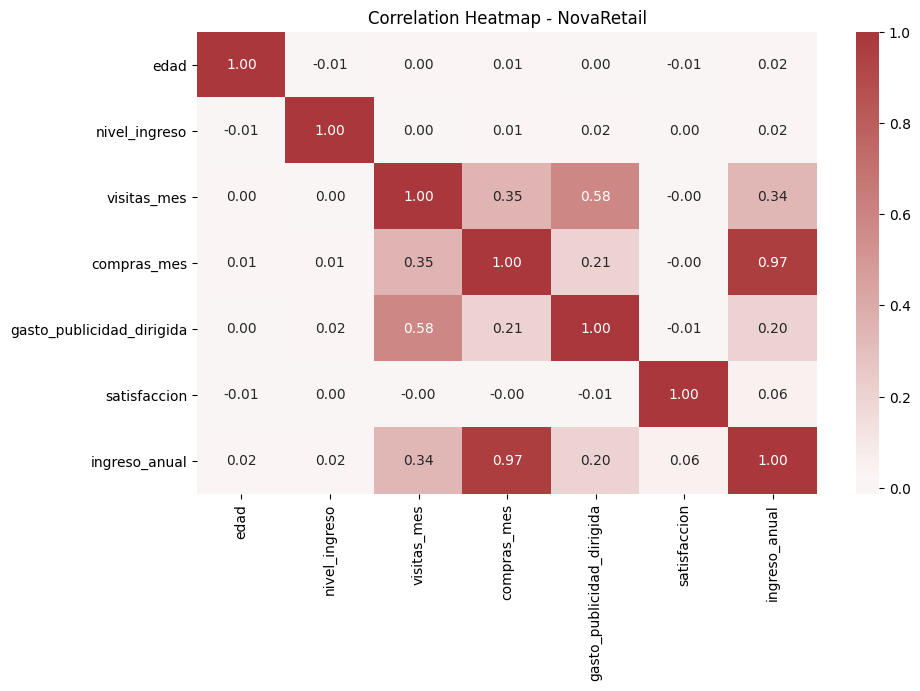

In [10]:
# Matriz de correlación de Pearson entre las variables numéricas
corr = df[col_num].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="vlag", fmt=".2f", center=0)
plt.title("Correlation Heatmap - NovaRetail")
plt.show()

**Observaciones generales**

- Se observa que la mayoría de las correlaciones son cercanas a 0: `edad`, `nivel_ingreso` y `satisfaccion` no muestran relación lineal con ninguna otra variable (valores entre -0.01 y 0.06).
- Se observa una correlación positiva moderada entre `visitas_mes` y `gasto_publicidad_dirigida` (0.58).
- Se observa una correlación positiva débil entre `visitas_mes` y `compras_mes` (0.35) y entre `compras_mes` y `gasto_publicidad_dirigida` (0.21): la publicidad se asocia más con las visitas que con las compras.
- Se observa que no hay correlaciones negativas relevantes entre las variables.

**Observaciones sobre `ingreso_anual`**

- Presenta una correlación muy fuerte con `compras_mes` (0.97). Un valor tan cercano a 1 sugiere redundancia: `ingreso_anual` parece ser prácticamente un derivado de `compras_mes` (compras por valor del ticket), por lo que ambas variables aportan casi la misma información y no deben tratarse como independientes.
- Presenta una correlación positiva débil con `visitas_mes` (0.34) y con `gasto_publicidad_dirigida` (0.20).
- Presenta una correlación prácticamente nula con `edad` (0.02), `nivel_ingreso` (0.02) y `satisfaccion` (0.06), por lo que estas variables no explican linealmente el ingreso.

### 3.2 Matriz de diagramas de dispersión

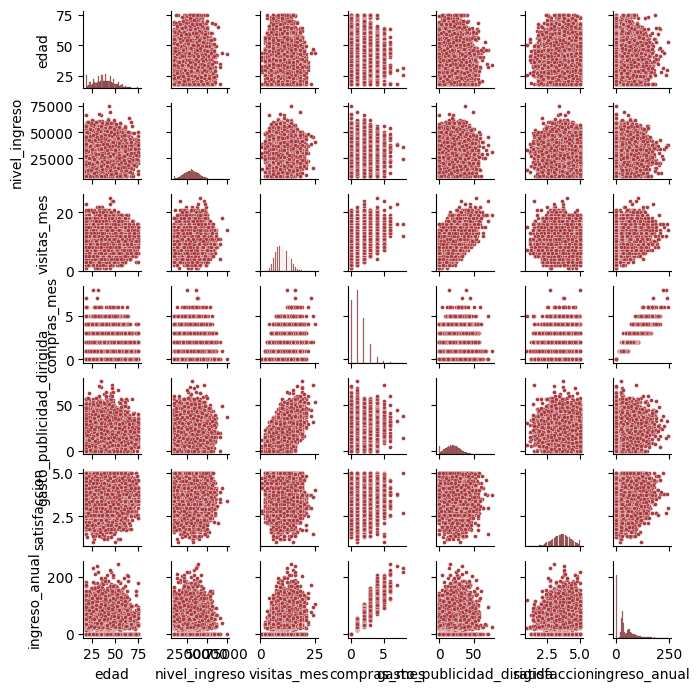

In [11]:
# Todas las variables numéricas, par por par
sns.pairplot(df[col_num], height=1,
    plot_kws={"color": "#A9373B", "s": 8},
    diag_kws={"color": "#A9373B"},
)
plt.show()

- `compras_mes` e `ingreso_anual` muestran una relación lineal positiva muy marcada, en forma escalonada porque `compras_mes` es una variable discreta. Esto confirma la correlación de 0.97.
- `visitas_mes` y `gasto_publicidad_dirigida` muestran una tendencia ascendente clara: a mayor gasto en publicidad dirigida, más visitas.
- `visitas_mes` presenta una tendencia positiva débil con `compras_mes` y con `ingreso_anual`, con alta dispersión.
- `edad`, `nivel_ingreso` y `satisfaccion` forman nubes de puntos sin patrón frente a todas las demás variables. No se observan relaciones no lineales que la correlación de Pearson hubiera pasado por alto.
- En `ingreso_anual` se observa una concentración de puntos en 0, correspondiente a los clientes sin compras.

En conclusión, el scatterplot general confirma los resultados del heatmap y descarta la presencia de relaciones no lineales relevantes.

### 3.3 Diagramas de dispersión de los pares clave

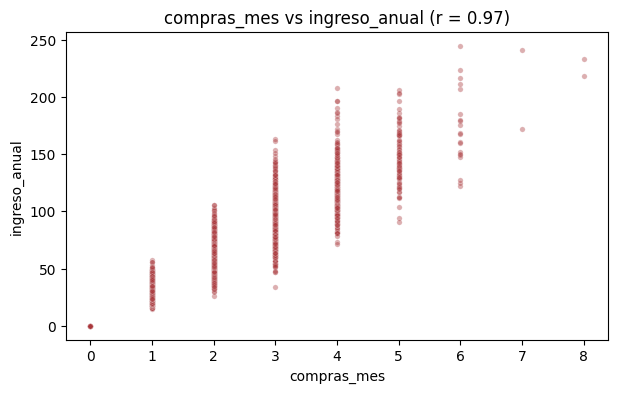

In [12]:
# Compras al mes e ingreso anual
plt.figure(figsize=(7, 4))
sns.scatterplot(data=df, x="compras_mes", y="ingreso_anual", color="#A9373B", s=15, alpha=0.4)
plt.title("compras_mes vs ingreso_anual (r = 0.97)")
plt.show()

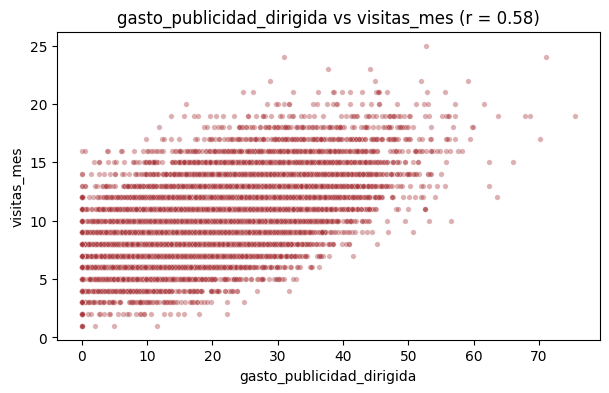

In [13]:
# Publicidad dirigida y visitas al mes
plt.figure(figsize=(7, 4))
sns.scatterplot(data=df, x="gasto_publicidad_dirigida", y="visitas_mes", color="#A9373B", s=15, alpha=0.4)
plt.title("gasto_publicidad_dirigida vs visitas_mes (r = 0.58)")
plt.show()

**compras_mes vs ingreso_anual**

- Dirección positiva y claramente lineal: a más compras al mes, mayor ingreso anual.
- Dispersión baja alrededor de la tendencia, aunque aumenta con el número de compras: con 1 compra el ingreso varía aproximadamente entre 15 y 60, y con 4 compras entre 70 y 210.
- Outliers: hay pocos clientes con 6 a 8 compras e ingresos superiores a 200; son valores atípicos en magnitud, pero siguen la misma tendencia del resto.
- Colinealidad alta (r = 0.97): con 0 compras el ingreso es siempre 0, lo que confirma que `ingreso_anual` se deriva de `compras_mes`. Ambas variables son redundantes y no deben usarse como independientes.

**gasto_publicidad_dirigida vs visitas_mes**

- Dirección positiva: a mayor gasto en publicidad dirigida, más visitas al mes.
- Dispersión media-alta: para un mismo nivel de gasto las visitas varían mucho (con un gasto de 20, entre 3 y 20 visitas), por lo que la publicidad explica solo una parte del comportamiento.
- Outliers: se observan pocos clientes con gasto superior a 60 y con más de 20 visitas. También destaca un grupo con gasto 0 que aun así registra entre 1 y 16 visitas.
- Colinealidad moderada (r = 0.58): las variables están relacionadas pero no son redundantes, cada una aporta información propia.

---
## 4. Coeficientes de correlación y evidencia numérica

Se reportan los coeficientes que respaldan los patrones observados en los gráficos, con el método adecuado para cada tipo de variable.

### 4.1 Pearson y Spearman

In [14]:
# Compras al mes e ingreso anual
pearson_corr = df["compras_mes"].corr(df["ingreso_anual"], method='pearson')
spearman_corr = df["compras_mes"].corr(df["ingreso_anual"], method='spearman')

print("Pearson:", pearson_corr)
print("Spearman:", spearman_corr)

Pearson: 0.9671485435708564
Spearman: 0.967482492032673


In [15]:
# Publicidad dirigida y visitas al mes
pearson_corr = df["gasto_publicidad_dirigida"].corr(df["visitas_mes"], method='pearson')
spearman_corr = df["gasto_publicidad_dirigida"].corr(df["visitas_mes"], method='spearman')

print("Pearson:", pearson_corr)
print("Spearman:", spearman_corr)

Pearson: 0.5789472719412827
Spearman: 0.5592673242622609


**compras_mes vs ingreso_anual**

- Correlación positiva muy fuerte: Pearson = 0.967 y Spearman = 0.967.
- Ambos coeficientes coinciden, lo que indica que la relación es lineal y consistente, sin distorsión por valores atípicos.
- Colinealidad alta: las dos variables aportan prácticamente la misma información, por lo que no deben usarse como independientes.

**gasto_publicidad_dirigida vs visitas_mes**

- Correlación positiva moderada: Pearson = 0.579 y Spearman = 0.559.
- Los dos coeficientes son muy similares, lo que indica una relación esencialmente lineal; el gasto en publicidad se asocia con más visitas, pero explica solo una parte de su variación.
- Sin colinealidad problemática: las variables están relacionadas pero cada una aporta información propia.

Nota sobre el método: como `compras_mes` y `visitas_mes` son variables discretas e `ingreso_anual` tiene un sesgo marcado, Spearman es el coeficiente más robusto en ambos casos; Pearson se reporta como referencia y confirma el mismo resultado.

### 4.2 Punto-biserial

In [16]:
# Cada variable binaria frente a cada variable numérica
for binaria in ["miembro_premium", "abandono"]:
    for num in col_num:
        r, p = pointbiserialr(df[binaria], df[num])
        print(f"{binaria} vs {num}: r = {r:.3f}, p = {p:.4f}")
    print()

miembro_premium vs edad: r = 0.005, p = 0.5728
miembro_premium vs nivel_ingreso: r = -0.006, p = 0.4930
miembro_premium vs visitas_mes: r = -0.013, p = 0.1211
miembro_premium vs compras_mes: r = 0.003, p = 0.6744
miembro_premium vs gasto_publicidad_dirigida: r = 0.003, p = 0.7390
miembro_premium vs satisfaccion: r = 0.026, p = 0.0016
miembro_premium vs ingreso_anual: r = 0.093, p = 0.0000

abandono vs edad: r = -0.012, p = 0.1590
abandono vs nivel_ingreso: r = 0.006, p = 0.4722
abandono vs visitas_mes: r = -0.009, p = 0.2734
abandono vs compras_mes: r = 0.008, p = 0.3099
abandono vs gasto_publicidad_dirigida: r = -0.005, p = 0.5744
abandono vs satisfaccion: r = -0.024, p = 0.0035
abandono vs ingreso_anual: r = -0.003, p = 0.7295



**miembro_premium vs ingreso_anual**

- Relación positiva de magnitud baja (r = 0.093, p < 0.001): los clientes premium tienden a generar un ingreso ligeramente mayor. Es la relación más alta de todas, pero sigue siendo débil.

**miembro_premium vs satisfaccion**

- Relación positiva de magnitud muy baja (r = 0.026, p = 0.0016): los clientes premium muestran una satisfacción apenas superior; el efecto es prácticamente nulo.

**abandono vs satisfaccion**

- Relación negativa de magnitud muy baja (r = -0.024, p = 0.0035): a menor satisfacción, levemente mayor abandono; el efecto es prácticamente nulo.

Observación general: el resto de combinaciones no es estadísticamente significativa (p > 0.05). Las tres relaciones reportadas sí lo son, pero esto se debe al tamaño de la muestra (15,000 registros), que permite detectar efectos mínimos; en la práctica, ninguna variable numérica explica por sí sola el abandono ni la membresía premium.

### 4.3 V de Cramér

In [17]:
# Función para calcular la V de Cramér
def cramer_v(df, col1, col2):
    # Tabla de contingencia
    tabla = pd.crosstab(df[col1], df[col2])

    # Chi-cuadrado
    chi2, p_value, dof, expected = chi2_contingency(tabla)

    # Coeficiente V de Cramér
    n = tabla.values.sum()
    v = np.sqrt(chi2 / (n * (min(tabla.shape) -1)))

    return v

In [18]:
# V de Cramér entre todos los pares de variables categóricas y binarias
print("abandono vs miembro_premium:", cramer_v(df, "abandono", "miembro_premium"))
print("abandono vs tipo_dispositivo:", cramer_v(df, "abandono", "tipo_dispositivo"))
print("abandono vs region:", cramer_v(df, "abandono", "region"))
print("miembro_premium vs tipo_dispositivo:", cramer_v(df, "miembro_premium", "tipo_dispositivo"))
print("miembro_premium vs region:", cramer_v(df, "miembro_premium", "region"))
print("tipo_dispositivo vs region:", cramer_v(df, "tipo_dispositivo", "region"))

abandono vs miembro_premium: 0.12021874609740511
abandono vs tipo_dispositivo: 0.007245190431994803
abandono vs region: 0.015429712175030079
miembro_premium vs tipo_dispositivo: 0.019725434455421662
miembro_premium vs region: 0.012574183027958333
tipo_dispositivo vs region: 0.012378338407739397


**abandono vs miembro_premium**

- Asociación débil pero la más alta de todas (V = 0.120): la membresía premium es la única variable categórica que muestra relación con el abandono.

**abandono vs tipo_dispositivo y abandono vs region**

- Asociación prácticamente nula (V = 0.007 y V = 0.015): el abandono se comporta igual sin importar el dispositivo o la región del cliente.

**miembro_premium vs tipo_dispositivo y miembro_premium vs region**

- Asociación prácticamente nula (V = 0.020 y V = 0.013): la proporción de clientes premium es similar en todos los dispositivos y regiones.

**tipo_dispositivo vs region**

- Asociación prácticamente nula (V = 0.012): las dos variables son independientes entre sí, no hay redundancia entre ellas.

Observación general: cinco de los seis pares tienen V menor a 0.02, es decir, las variables categóricas son independientes entre sí. La única excepción es `abandono` con `miembro_premium`, que aunque débil es unas ocho veces mayor que el resto.

---
## 5. Interpretación de resultados para el negocio

Cada hallazgo se presenta con su evidencia visual y numérica, una interpretación no causal, lo que los datos no permiten afirmar y la implicación para el negocio.

### 5.1. Hallazgo 1 — Compras mensuales e ingreso anual

**Evidencia visual:** Heatmap, scatterplot general y scatterplot de pares clave (relación lineal en forma escalonada).<br>
**Evidencia numérica:** Pearson = 0.967; Spearman = 0.967.

**Interpretación**

Los clientes con más compras al mes tienden a registrar un mayor ingreso anual. La relación es muy fuerte y casi idéntica en ambos coeficientes, lo que sugiere que `ingreso_anual` se deriva en gran parte de `compras_mes`: las dos variables miden prácticamente lo mismo.

**No podemos afirmar**

Que sean dos factores independientes ni que una cause a la otra. Una correlación tan alta apunta a redundancia entre variables, no a un patrón de comportamiento del cliente.

**Implicación de negocio**

No conviene usar ambas variables a la vez en segmentaciones o modelos, porque se contaría dos veces la misma información. Se recomienda elegir una como métrica principal y confirmar cómo se calcula `ingreso_anual`.

### 5.2. Hallazgo 2 — Publicidad dirigida, visitas y compras

**Evidencia visual:** Heatmap y scatterplot de pares clave (tendencia ascendente con dispersión media-alta).<br>
**Evidencia numérica:** `gasto_publicidad_dirigida` vs `visitas_mes`: Pearson = 0.579, Spearman = 0.559. `gasto_publicidad_dirigida` vs `compras_mes`: Pearson = 0.21 (heatmap).

**Interpretación**

Los clientes con mayor gasto en publicidad dirigida tienden a visitar más la tienda, con una relación moderada. La asociación de la publicidad con las compras es bastante más débil que con las visitas.

**No podemos afirmar**

Que la publicidad cause más visitas o más compras. Es posible que la inversión publicitaria se dirija a clientes que ya eran más activos, o que influyan factores no medidos como promociones o antigüedad del cliente.

**Implicación de negocio**

Antes de modificar el presupuesto, conviene validar con un experimento controlado si la publicidad aumenta las visitas y si esas visitas se convierten en compras. También vale la pena analizar el paso de visita a compra, donde la relación se debilita.

### 5.3. Hallazgo 3 — Membresía premium y abandono

**Evidencia visual:** No aplica (variables categóricas); se usa tabla de contingencia.<br>
**Evidencia numérica:** V de Cramér = 0.120, la más alta entre los pares categóricos (el resto es menor a 0.02). Tasa de abandono: 4.4% en clientes premium frente a 16.8% en no premium.

**Interpretación**

Los clientes premium tienden a abandonar menos. La asociación es débil en magnitud, pero es la única variable del análisis que muestra relación con el abandono.

**No podemos afirmar**

Que la membresía premium reduzca el abandono. Es posible que los clientes más comprometidos sean quienes eligen hacerse premium. Además, los premium son solo el 13.9% de la base, un grupo pequeño frente al resto.

**Implicación de negocio**

Se recomienda analizar por cohortes y antigüedad si la diferencia se mantiene y, de ser viable, probar con un experimento el efecto de incentivar la membresía. No debe usarse como criterio único para predecir el abandono.

### 5.4. Hallazgo 4 — Perfil del cliente sin asociación con el comportamiento

**Evidencia visual:** Heatmap y scatterplot general (nubes de puntos sin patrón).<br>
**Evidencia numérica:** `edad`, `nivel_ingreso` y `satisfaccion` tienen correlaciones de Pearson entre -0.01 y 0.06 con las demás variables. Frente al abandono: punto-biserial entre -0.024 y 0.006; V de Cramér = 0.015 (región) y 0.007 (tipo de dispositivo).

**Interpretación**

La edad, el nivel de ingreso, la región y el tipo de dispositivo no muestran asociación con las compras, el ingreso generado ni el abandono: el comportamiento es similar en todos los segmentos. Llama la atención que la satisfacción tampoco se asocie de forma relevante con el abandono.

**No podemos afirmar**

Que estas variables no influyan en absoluto. Los coeficientes miden asociaciones globales y podrían existir efectos dentro de subgrupos que no se exploraron en este análisis.

**Implicación de negocio**

No hay evidencia para priorizar ni excluir segmentos por edad, ingreso, región o dispositivo. Conviene revisar cómo se mide la satisfacción y segmentar el análisis antes de sacar conclusiones sobre algún grupo.

---
## 6. Limitaciones y próximos pasos

### 6.1. Limitaciones

- Correlación ≠ causalidad: el análisis es exploratorio y solo describe asociaciones entre variables, no demuestra que una cause a la otra.
- Variables no controladas: no se cuenta con información sobre antigüedad del cliente, promociones, campañas o precios, que podrían explicar parte de las relaciones observadas.
- Análisis global: los coeficientes se calcularon sobre toda la base, sin segmentar. Podrían existir efectos distintos dentro de subgrupos (paradoja de Simpson) que no se exploraron.
- Redundancia entre variables: `ingreso_anual` y `compras_mes` miden prácticamente lo mismo (r = 0.97), lo que limita su uso conjunto.
- Grupos desbalanceados: solo el 13.9% de los clientes es premium y el 15.1% abandonó, por lo que las conclusiones sobre estos grupos se basan en muestras más pequeñas.
- Valores atípicos: los valores atípicos detectados con la regla IQR se mantuvieron en el análisis y podrían influir en algunos coeficientes.
- Datos de un solo momento: la base no incluye fechas, por lo que no es posible analizar cómo evolucionan las relaciones en el tiempo.

### 6.2. Próximos pasos

**Probar segmentación adicional**

- Repetir las correlaciones separando clientes premium y no premium, para verificar si los patrones globales se mantienen en cada grupo.
- Segmentar por `tipo_dispositivo` y `region` para descartar diferencias ocultas en el promedio general.

**Validar las relaciones con experimentos controlados**

- Realizar una prueba A/B de publicidad dirigida para medir su efecto real sobre las visitas y las compras.
- Evaluar con un piloto si incentivar la membresía premium se asocia con menor abandono.

**Profundizar en el abandono y depurar variables**

- Analizar el abandono por cohortes y antigüedad, incorporando variables no disponibles en esta base.
- Revisar cómo se mide la satisfacción, dado que no mostró relación con el abandono.
- Confirmar cómo se calcula `ingreso_anual` y definir una sola métrica principal entre esta y `compras_mes`.